In [1]:
import sys

print(sys.executable)

C:\Users\newto\Desktop\cohort-retention-analysis\.venv\Scripts\python.exe


In [ ]:
print(orders_retention.columns.tolist())

In [3]:
# Delivered sifarişlər
orders_retention = orders[
    orders["order_status"] == "delivered"
].merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# İlk delivered alış
first_purchase_unique = (
    orders_retention
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase_unique.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

# Cohort ayı
first_purchase_unique["cohort_month"] = (
    first_purchase_unique["first_purchase_date"]
    .dt.to_period("M")
)

# Cohort məlumatını sifarişlərə əlavə edirik
orders_retention = orders_retention.merge(
    first_purchase_unique[
        ["customer_unique_id", "cohort_month"]
    ],
    on="customer_unique_id",
    how="left"
)

# Sifariş ayı
orders_retention["order_month"] = (
    orders_retention["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Retention period
orders_retention["retention_month"] = (
    (orders_retention["order_month"] - orders_retention["cohort_month"])
    .apply(lambda x: x.n)
)

print("Delivered orders:", len(orders_retention))
print("Unique delivered customers:",
      orders_retention["customer_unique_id"].nunique())

print(
    orders_retention[
        ["customer_unique_id",
         "cohort_month",
         "order_month",
         "retention_month"]
    ].head()
)

NameError: name 'orders' is not defined

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("Environment is ready!")

pandas: 3.0.6
seaborn: 0.13.2
Environment is ready!


In [ ]:
print(orders_retention.columns.tolist())

In [5]:
# 1. Yalnız delivered sifarişləri götürürük
orders_retention = orders[
    orders["order_status"] == "delivered"
].merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# 2. İlk delivered alış
first_purchase_unique = (
    orders_retention
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase_unique.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

# 3. Cohort ayı
first_purchase_unique["cohort_month"] = (
    first_purchase_unique["first_purchase_date"]
    .dt.to_period("M")
)

# 4. Cohort məlumatını əlavə edirik
orders_retention = orders_retention.merge(
    first_purchase_unique[
        ["customer_unique_id", "cohort_month"]
    ],
    on="customer_unique_id",
    how="left"
)

# 5. Sifariş ayı
orders_retention["order_month"] = (
    orders_retention["order_purchase_timestamp"]
    .dt.to_period("M")
)

# 6. Retention ayı
orders_retention["retention_month"] = (
    (orders_retention["order_month"] - orders_retention["cohort_month"])
    .apply(lambda x: x.n)
)

# 7. Yoxlama
print("Delivered orders:", len(orders_retention))
print("Unique delivered customers:",
      orders_retention["customer_unique_id"].nunique())

print(
    orders_retention[
        [
            "customer_unique_id",
            "cohort_month",
            "order_month",
            "retention_month"
        ]
    ].head()
)

NameError: name 'orders' is not defined

In [6]:
import pandas as pd

customers = pd.read_csv("data/olist_customers_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

print("Customers:", customers.shape)
print("Orders:", orders.shape)

Customers: (99441, 5)
Orders: (99441, 8)


In [3]:
import pandas as pd
import sqlite3
from pathlib import Path

In [7]:
orders_retention = orders[
    orders["order_status"] == "delivered"
].merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

first_purchase_unique = (
    orders_retention
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase_unique.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

first_purchase_unique["cohort_month"] = (
    first_purchase_unique["first_purchase_date"]
    .dt.to_period("M")
)

orders_retention = orders_retention.merge(
    first_purchase_unique[
        ["customer_unique_id", "cohort_month"]
    ],
    on="customer_unique_id",
    how="left"
)

orders_retention["order_month"] = (
    orders_retention["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders_retention["retention_month"] = (
    (orders_retention["order_month"] - orders_retention["cohort_month"])
    .apply(lambda x: x.n)
)

print("Delivered orders:", len(orders_retention))
print("Unique delivered customers:",
      orders_retention["customer_unique_id"].nunique())

print(
    orders_retention[
        ["customer_unique_id", "cohort_month",
         "order_month", "retention_month"]
    ].head()
)

Delivered orders: 96478
Unique delivered customers: 93358
                 customer_unique_id cohort_month order_month  retention_month
0  7c396fd4830fd04220f754e42b4e5bff      2017-09     2017-10                1
1  af07308b275d755c9edb36a90c618231      2018-07     2018-07                0
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08     2018-08                0
3  7c142cf63193a1473d2e66489a9ae977      2017-11     2017-11                0
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02     2018-02                0


In [1]:
print(orders_retention.columns.tolist())

NameError: name 'orders_retention' is not defined

In [8]:
import pandas as pd

customers = pd.read_csv("data/olist_customers_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders_retention = orders[
    orders["order_status"] == "delivered"
].merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

first_purchase_unique = (
    orders_retention
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase_unique.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

first_purchase_unique["cohort_month"] = (
    first_purchase_unique["first_purchase_date"]
    .dt.to_period("M")
)

orders_retention = orders_retention.merge(
    first_purchase_unique[
        ["customer_unique_id", "cohort_month"]
    ],
    on="customer_unique_id",
    how="left"
)

orders_retention["order_month"] = (
    orders_retention["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders_retention["retention_month"] = (
    (orders_retention["order_month"] - orders_retention["cohort_month"])
    .apply(lambda x: x.n)
)

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Delivered orders:", len(orders_retention))
print(
    "Unique delivered customers:",
    orders_retention["customer_unique_id"].nunique()
)

Customers: (99441, 5)
Orders: (99441, 8)
Delivered orders: 96478
Unique delivered customers: 93358


In [9]:
# 1. Cohort üzrə aktiv müştəri sayı
cohort_data = (
    orders_retention
    .groupby(
        ["cohort_month", "retention_month"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

# 2. Cohort retention matrix
cohort_matrix = cohort_data.pivot(
    index="cohort_month",
    columns="retention_month",
    values="customer_unique_id"
)

# 3. Cohort ölçüsü = Period 0
cohort_size = cohort_matrix.iloc[:, 0]

# 4. Retention faizləri
retention_matrix_pct = (
    cohort_matrix
    .divide(cohort_size, axis=0)
    * 100
)

# 5. Nəticəni göstər
print("Cohort size:")
print(cohort_size.head())

print("\nRetention matrix (%):")
display(retention_matrix_pct.round(2))

# 6. Heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Retention Analysis - Delivered Orders")
plt.xlabel("Months Since First Delivered Purchase")
plt.ylabel("Cohort Month")
plt.show()

Cohort size:
cohort_month
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
Freq: M, Name: 0, dtype: float64

Retention matrix (%):


retention_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN


NameError: name 'plt' is not defined

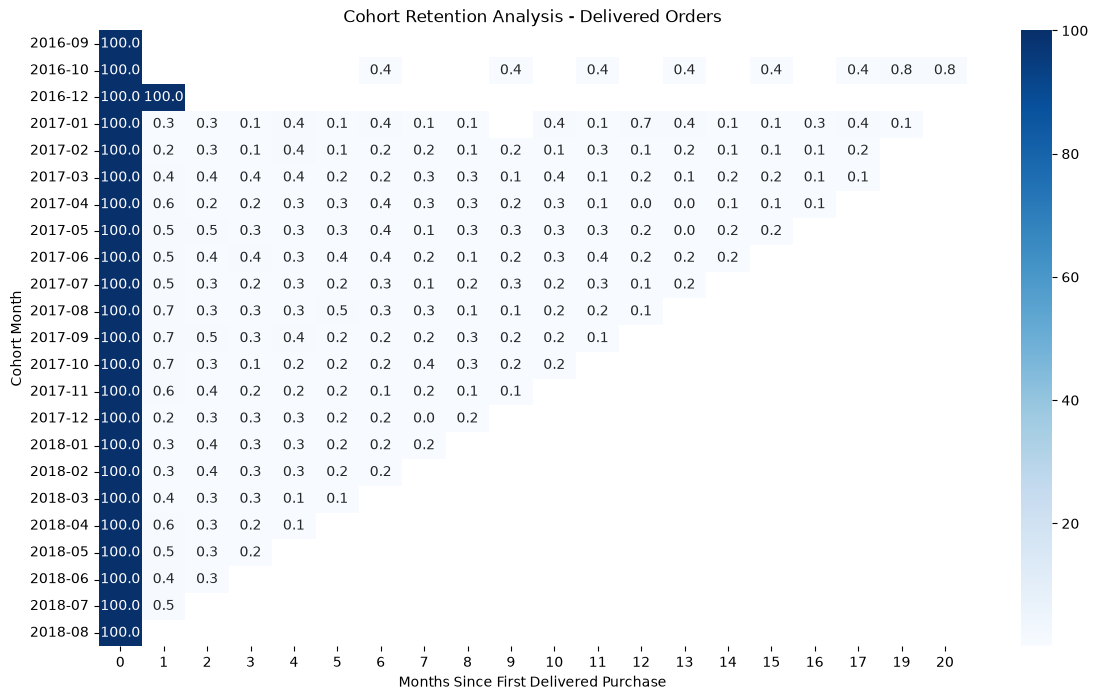

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Retention Analysis - Delivered Orders")
plt.xlabel("Months Since First Delivered Purchase")
plt.ylabel("Cohort Month")
plt.show()

Average retention by period:
retention_month
0     100.00
1       5.45
2       0.34
3       0.25
4       0.29
5       0.23
6       0.27
7       0.21
8       0.21
9       0.19
10      0.26
11      0.23
12      0.21
13      0.20
14      0.15
15      0.19
16      0.14
17      0.28
19      0.45
20      0.76
dtype: float64


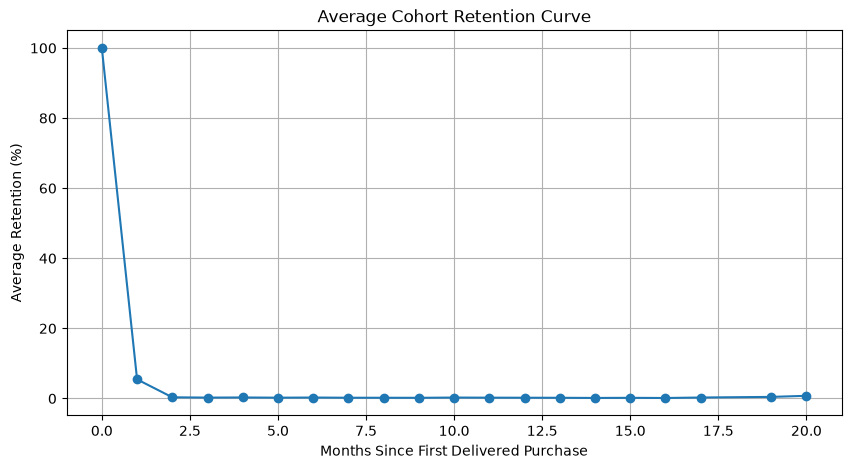

In [11]:
# Average retention by month
average_retention = retention_matrix_pct.mean(axis=0)

print("Average retention by period:")
print(average_retention.round(2))

plt.figure(figsize=(10, 5))

plt.plot(
    average_retention.index,
    average_retention.values,
    marker="o"
)

plt.title("Average Cohort Retention Curve")
plt.xlabel("Months Since First Delivered Purchase")
plt.ylabel("Average Retention (%)")
plt.grid(True)
plt.show()

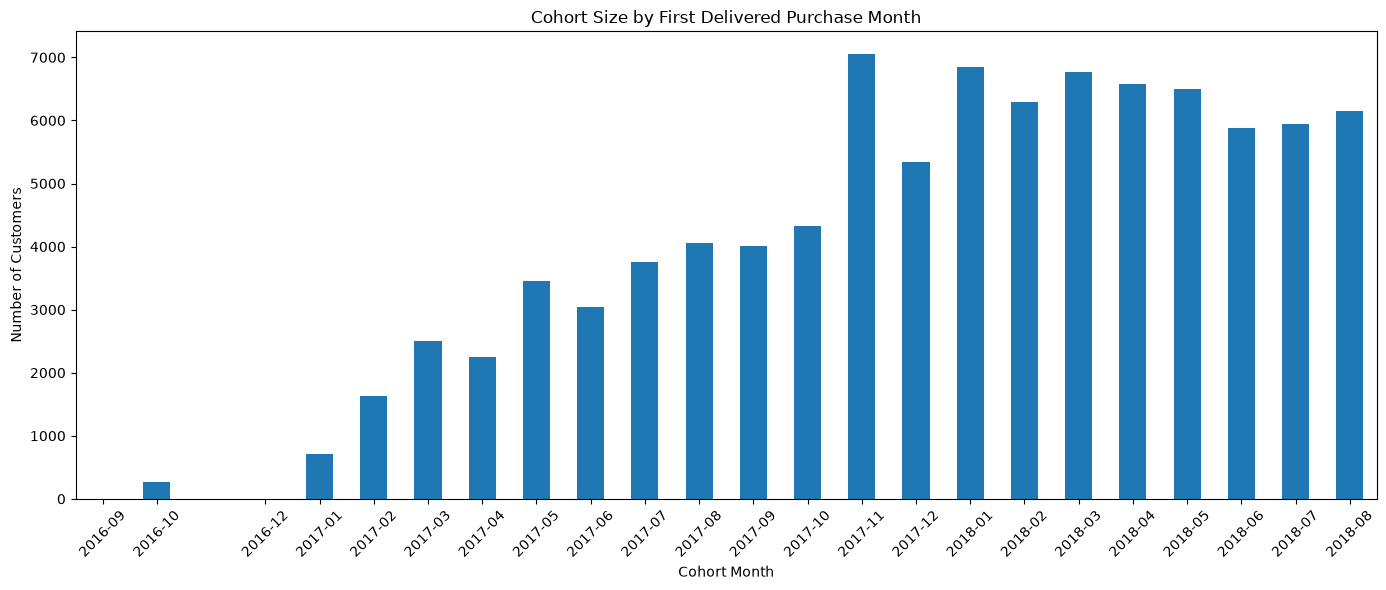

In [12]:
plt.figure(figsize=(14, 6))

cohort_size.sort_index().plot(kind="bar")

plt.title("Cohort Size by First Delivered Purchase Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
data_path = Path("data")

orders = pd.read_csv(data_path / "olist_orders_dataset.csv")
customers = pd.read_csv(data_path / "olist_customers_dataset.csv")
order_items = pd.read_csv(data_path / "olist_order_items_dataset.csv")
order_reviews = pd.read_csv(data_path / "olist_order_reviews_dataset.csv")

In [2]:
print(orders_retention.columns.tolist())

NameError: name 'orders_retention' is not defined

In [5]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order items:", order_items.shape)
print("Order reviews:", order_reviews.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)
Order reviews: (99224, 7)


In [7]:
import pandas as pd
import sqlite3
from pathlib import Path

In [8]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order items:", order_items.shape)
print("Order reviews:", order_reviews.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)
Order reviews: (99224, 7)


In [9]:
conn = sqlite3.connect("cohort_retention.db")

In [10]:
orders.to_sql("orders", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
order_reviews.to_sql("order_reviews", conn, if_exists="replace", index=False)

99224

In [11]:
query = """
SELECT COUNT(*) AS order_count
FROM orders;
"""

pd.read_sql_query(query, conn)

,order_count
0,99441


In [12]:
query = """
SELECT
    order_id,
    customer_id,
    order_purchase_timestamp,
    order_status
FROM orders
WHERE order_status = 'delivered';
"""

delivered_orders = pd.read_sql_query(query, conn)

delivered_orders.head()

,order_id,customer_id,order_purchase_timestamp,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered


In [13]:
query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

delivered_activity = pd.read_sql_query(query, conn)

delivered_activity.head()query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

delivered_activity = pd.read_sql_query(query, conn)

delivered_activity.head()

SyntaxError: invalid syntax (3255825792.py, line 14)

In [14]:
query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

delivered_activity = pd.read_sql_query(query, conn)

delivered_activity.head()

,order_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [15]:
query = """
SELECT
    customer_unique_id,
    MIN(order_purchase_timestamp) AS first_purchase_date
FROM delivered_activity
GROUP BY customer_unique_id;
"""

In [16]:
delivered_activity.to_sql(
    "delivered_activity",
    conn,
    if_exists="replace",
    index=False
)

96478

In [17]:
query = """
SELECT
    customer_unique_id,
    MIN(order_purchase_timestamp) AS first_purchase_date
FROM delivered_activity
GROUP BY customer_unique_id;
"""

cohort_data = pd.read_sql_query(query, conn)

cohort_data.head()

,customer_unique_id,first_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [18]:
query = """
SELECT
    customer_unique_id,
    strftime('%Y-%m', MIN(order_purchase_timestamp)) AS cohort_month
FROM delivered_activity
GROUP BY customer_unique_id
ORDER BY cohort_month;
"""

cohort_data = pd.read_sql_query(query, conn)

cohort_data.head()

,customer_unique_id,cohort_month
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09
1,0032c76b20340da25249092a268ce66c,2016-10
2,01f156677184504063bd19739f924af1,2016-10
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10


In [19]:
cohort_data.to_sql(
    "cohort_data",
    conn,
    if_exists="replace",
    index=False
)

93358

In [20]:
query = """
SELECT
    a.customer_unique_id,
    c.cohort_month,
    strftime('%Y-%m', a.order_purchase_timestamp) AS order_month,
    (
        (CAST(strftime('%Y', a.order_purchase_timestamp) AS INTEGER) -
         CAST(substr(c.cohort_month, 1, 4) AS INTEGER)) * 12
        +
        (CAST(strftime('%m', a.order_purchase_timestamp) AS INTEGER) -
         CAST(substr(c.cohort_month, 6, 2) AS INTEGER))
    ) AS period_number
FROM delivered_activity AS a
JOIN cohort_data AS c
    ON a.customer_unique_id = c.customer_unique_id
ORDER BY c.cohort_month, a.customer_unique_id;
"""

activity_with_period = pd.read_sql_query(query, conn)

activity_with_period.head()

,customer_unique_id,cohort_month,order_month,period_number
0,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09,2016-09,0
1,0032c76b20340da25249092a268ce66c,2016-10,2016-10,0
2,01f156677184504063bd19739f924af1,2016-10,2016-10,0
3,0636d30c77f0f9cfad81f1c9b58c791f,2016-10,2016-10,0
4,06bdfbbe1857c3c925ec81abfb1c9666,2016-10,2016-10,0


In [21]:
activity_with_period.to_sql(
    "activity_with_period",
    conn,
    if_exists="replace",
    index=False
)

96478

In [22]:
query = """
SELECT
    cohort_month,
    period_number,
    COUNT(DISTINCT customer_unique_id) AS active_customers
FROM activity_with_period
GROUP BY cohort_month, period_number
ORDER BY cohort_month, period_number;
"""

retention_matrix = pd.read_sql_query(query, conn)

retention_matrix.head(20)

,cohort_month,period_number,active_customers
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


In [23]:
query = """
SELECT
    cohort_month,
    COUNT(DISTINCT customer_unique_id) AS cohort_size
FROM activity_with_period
WHERE period_number = 0
GROUP BY cohort_month
ORDER BY cohort_month;
"""

cohort_sizes = pd.read_sql_query(query, conn)

cohort_sizes.head(20)

,cohort_month,cohort_size
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,1628
5,2017-03,2503
6,2017-04,2256
7,2017-05,3451
8,2017-06,3037
9,2017-07,3752


In [24]:
query = """
SELECT
    r.cohort_month,
    r.period_number,
    r.active_customers,
    c.cohort_size,
    ROUND(
        100.0 * r.active_customers / c.cohort_size,
        2
    ) AS retention_rate
FROM retention_matrix AS r
JOIN cohort_sizes AS c
    ON r.cohort_month = c.cohort_month
ORDER BY r.cohort_month, r.period_number;
"""

retention_rates = pd.read_sql_query(query, conn)

retention_rates.head(20)

DatabaseError: Execution failed on sql '
SELECT
    r.cohort_month,
    r.period_number,
    r.active_customers,
    c.cohort_size,
    ROUND(
        100.0 * r.active_customers / c.cohort_size,
        2
    ) AS retention_rate
FROM retention_matrix AS r
JOIN cohort_sizes AS c
    ON r.cohort_month = c.cohort_month
ORDER BY r.cohort_month, r.period_number;
': no such table: retention_matrix

In [25]:
retention_matrix.to_sql(
    "retention_matrix",
    conn,
    if_exists="replace",
    index=False
)

219

In [26]:
cohort_sizes.to_sql(
    "cohort_sizes",
    conn,
    if_exists="replace",
    index=False
)

23

In [27]:
query = """
SELECT
    r.cohort_month,
    r.period_number,
    r.active_customers,
    c.cohort_size,
    ROUND(
        100.0 * r.active_customers / c.cohort_size,
        2
    ) AS retention_rate
FROM retention_matrix AS r
JOIN cohort_sizes AS c
    ON r.cohort_month = c.cohort_month
ORDER BY r.cohort_month, r.period_number;
"""

retention_rates = pd.read_sql_query(query, conn)

retention_rates.head(20)

,cohort_month,period_number,active_customers,cohort_size,retention_rate
0,2016-09,0,1,1,100.00
1,2016-10,0,262,262,100.00
2,2016-10,6,1,262,0.38
3,2016-10,9,1,262,0.38
4,2016-10,11,1,262,0.38
5,2016-10,13,1,262,0.38
6,2016-10,15,1,262,0.38
7,2016-10,17,1,262,0.38
8,2016-10,19,2,262,0.76
9,2016-10,20,2,262,0.76


In [28]:
retention_rates.to_sql(
    "retention_rates",
    conn,
    if_exists="replace",
    index=False
)

219

In [29]:
retention_rates.head()

,cohort_month,period_number,active_customers,cohort_size,retention_rate
0,2016-09,0,1,1,100.00
1,2016-10,0,262,262,100.00
2,2016-10,6,1,262,0.38
3,2016-10,9,1,262,0.38
4,2016-10,11,1,262,0.38


In [30]:
retention_rates.to_sql(
    "retention_rates",
    conn,
    if_exists="replace",
    index=False
)

219

In [31]:
query = """
SELECT
    period_number,
    ROUND(AVG(retention_rate), 2) AS average_retention_rate
FROM retention_rates
GROUP BY period_number
ORDER BY period_number;
"""

average_retention = pd.read_sql_query(query, conn)

average_retention.head(20)

,period_number,average_retention_rate
0,0,100.00
1,1,5.45
2,2,0.34
3,3,0.25
4,4,0.29
5,5,0.23
6,6,0.27
7,7,0.21
8,8,0.21
9,9,0.19


In [32]:
query = """
SELECT
    cohort_month,
    retention_rate AS month_1_retention
FROM retention_rates
WHERE period_number = 1
ORDER BY month_1_retention DESC;
"""

month_1_retention = pd.read_sql_query(query, conn)

month_1_retention

,cohort_month,month_1_retention
0,2016-12,100.00
1,2017-10,0.72
2,2017-09,0.70
3,2017-08,0.69
4,2017-04,0.62
5,2018-04,0.59
6,2017-11,0.57
7,2017-07,0.53
8,2018-05,0.52
9,2018-07,0.52


In [33]:
query = """
PRAGMA table_info(order_items);
"""

pd.read_sql_query(query, conn)query = """
PRAGMA table_info(order_items);
"""

pd.read_sql_query(query, conn)

SyntaxError: invalid syntax (2382619882.py, line 5)

In [34]:
query = """
PRAGMA table_info(order_items);
"""

pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,order_item_id,INTEGER,0,None,0
2,2,product_id,TEXT,0,None,0
3,3,seller_id,TEXT,0,None,0
4,4,shipping_limit_date,TEXT,0,None,0
5,5,price,REAL,0,None,0
6,6,freight_value,REAL,0,None,0


In [35]:
query = """
SELECT
    c.cohort_month,
    a.period_number,
    ROUND(SUM(oi.price), 2) AS revenue
FROM activity_with_period AS a
JOIN orders AS o
    ON a.order_id = o.order_id
JOIN order_items AS oi
    ON o.order_id = oi.order_id
JOIN cohort_data AS c
    ON a.customer_unique_id = c.customer_unique_id
GROUP BY
    c.cohort_month,
    a.period_number
ORDER BY
    c.cohort_month,
    a.period_number;
"""

cohort_revenue = pd.read_sql_query(query, conn)

cohort_revenue.head(20)

DatabaseError: Execution failed on sql '
SELECT
    c.cohort_month,
    a.period_number,
    ROUND(SUM(oi.price), 2) AS revenue
FROM activity_with_period AS a
JOIN orders AS o
    ON a.order_id = o.order_id
JOIN order_items AS oi
    ON o.order_id = oi.order_id
JOIN cohort_data AS c
    ON a.customer_unique_id = c.customer_unique_id
GROUP BY
    c.cohort_month,
    a.period_number
ORDER BY
    c.cohort_month,
    a.period_number;
': no such column: a.order_id

In [36]:
query = """
SELECT
    c.cohort_month,
    (
        (CAST(strftime('%Y', o.order_purchase_timestamp) AS INTEGER) -
         CAST(substr(c.cohort_month, 1, 4) AS INTEGER)) * 12
        +
        (CAST(strftime('%m', o.order_purchase_timestamp) AS INTEGER) -
         CAST(substr(c.cohort_month, 6, 2) AS INTEGER))
    ) AS period_number,
    ROUND(SUM(oi.price), 2) AS revenue
FROM orders AS o
JOIN customers AS cu
    ON o.customer_id = cu.customer_id
JOIN cohort_data AS c
    ON cu.customer_unique_id = c.customer_unique_id
JOIN order_items AS oi
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY
    c.cohort_month,
    period_number
ORDER BY
    c.cohort_month,
    period_number;
"""

cohort_revenue = pd.read_sql_query(query, conn)

cohort_revenue.head(20)

,cohort_month,period_number,revenue
0,2016-09,0,134.97
1,2016-10,0,40325.11
2,2016-10,6,99.99
3,2016-10,9,339.00
4,2016-10,11,49.00
5,2016-10,13,115.20
6,2016-10,15,298.60
7,2016-10,17,98.00
8,2016-10,19,289.28
9,2016-10,20,158.39


In [37]:
retention_rates.head(10)

,cohort_month,period_number,active_customers,cohort_size,retention_rate
0,2016-09,0,1,1,100.00
1,2016-10,0,262,262,100.00
2,2016-10,6,1,262,0.38
3,2016-10,9,1,262,0.38
4,2016-10,11,1,262,0.38
5,2016-10,13,1,262,0.38
6,2016-10,15,1,262,0.38
7,2016-10,17,1,262,0.38
8,2016-10,19,2,262,0.76
9,2016-10,20,2,262,0.76


In [38]:
heatmap_data = retention_rates.pivot(
    index="cohort_month",
    columns="period_number",
    values="retention_rate"
)

heatmap_data

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN


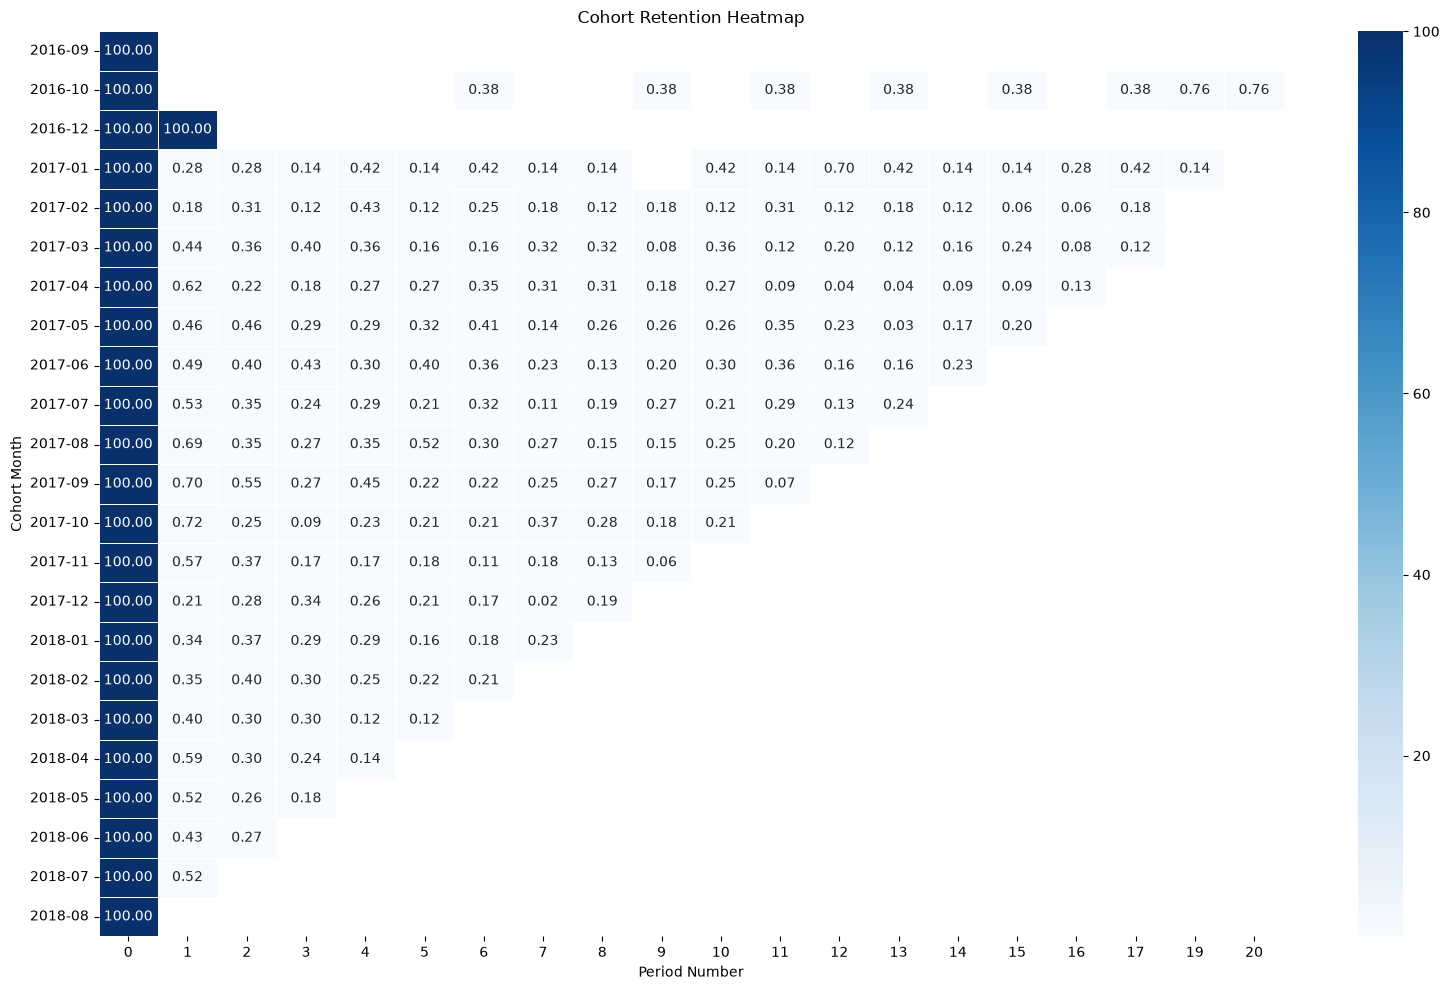

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Cohort Retention Heatmap")
plt.xlabel("Period Number")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

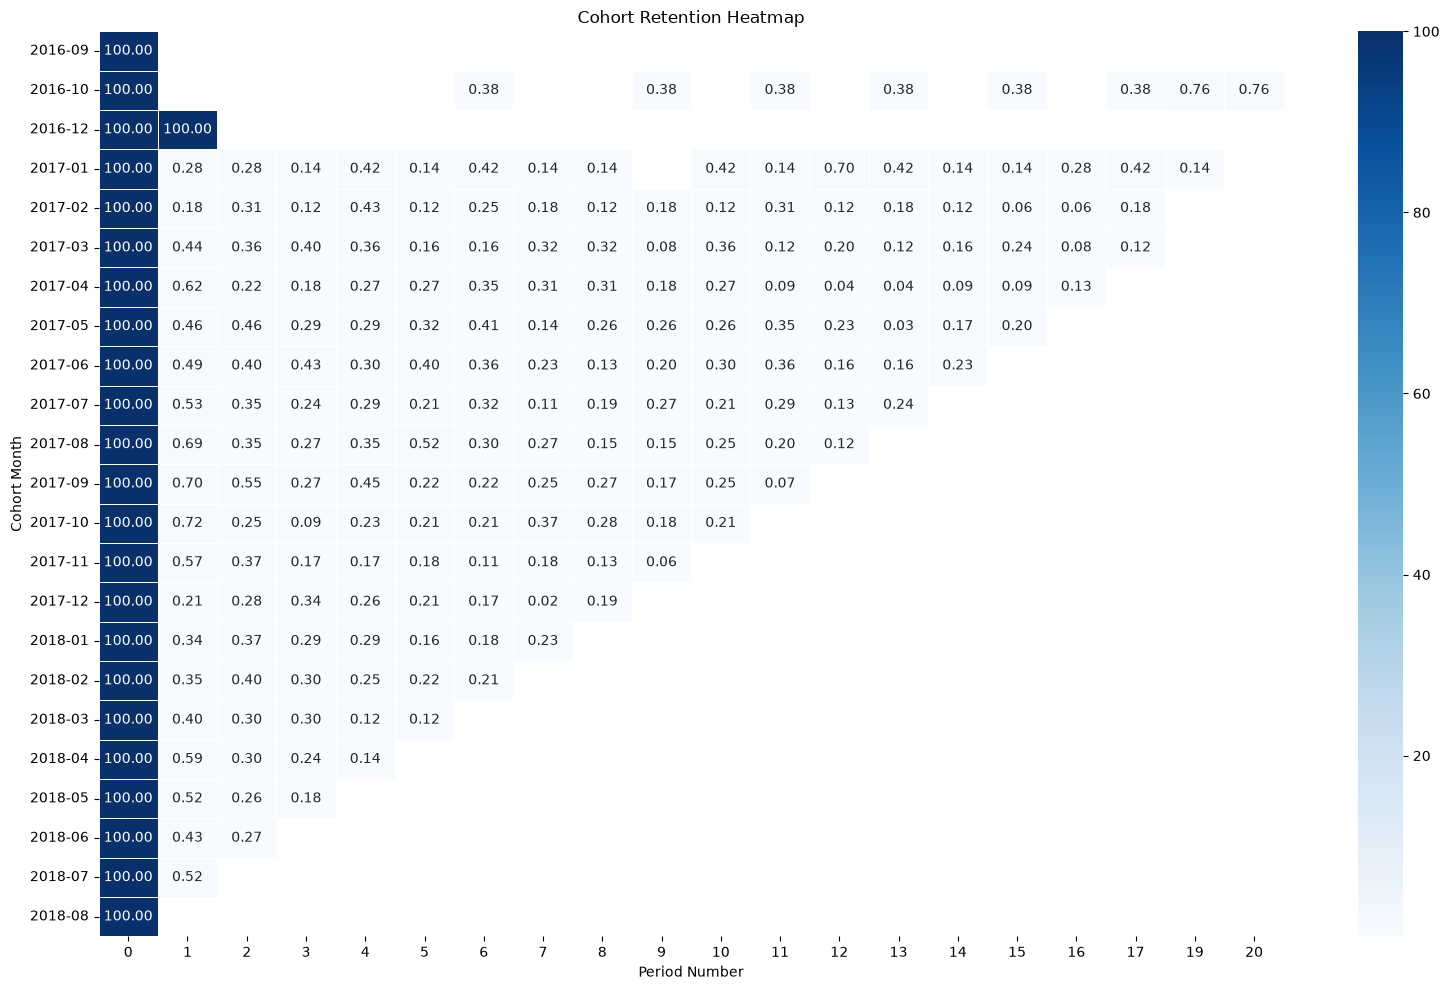

In [40]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Cohort Retention Heatmap")
plt.xlabel("Period Number")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

In [41]:
average_retention.head(20)

,period_number,average_retention_rate
0,0,100.00
1,1,5.45
2,2,0.34
3,3,0.25
4,4,0.29
5,5,0.23
6,6,0.27
7,7,0.21
8,8,0.21
9,9,0.19


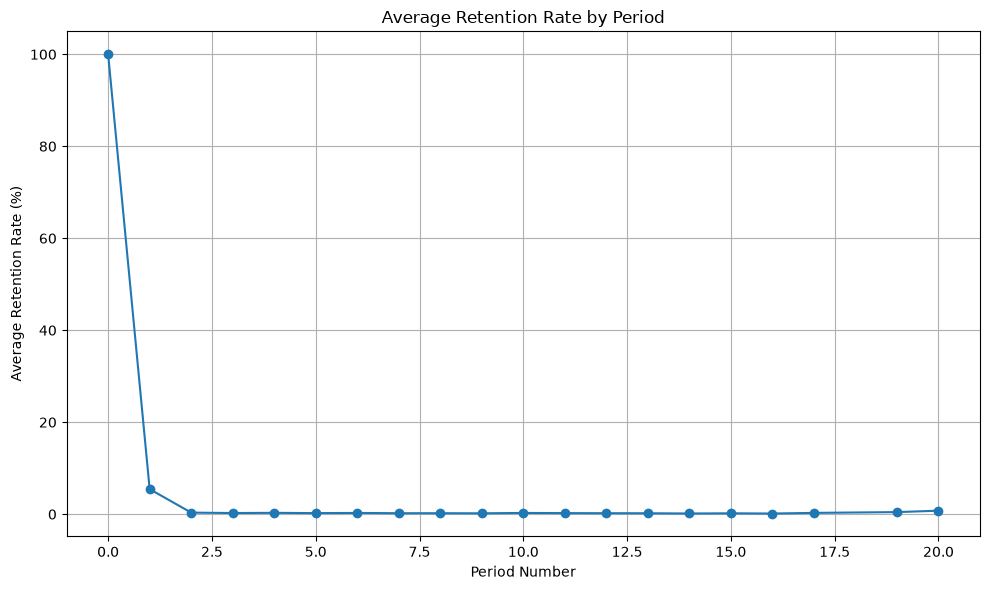

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    average_retention["period_number"],
    average_retention["average_retention_rate"],
    marker="o"
)

plt.title("Average Retention Rate by Period")
plt.xlabel("Period Number")
plt.ylabel("Average Retention Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

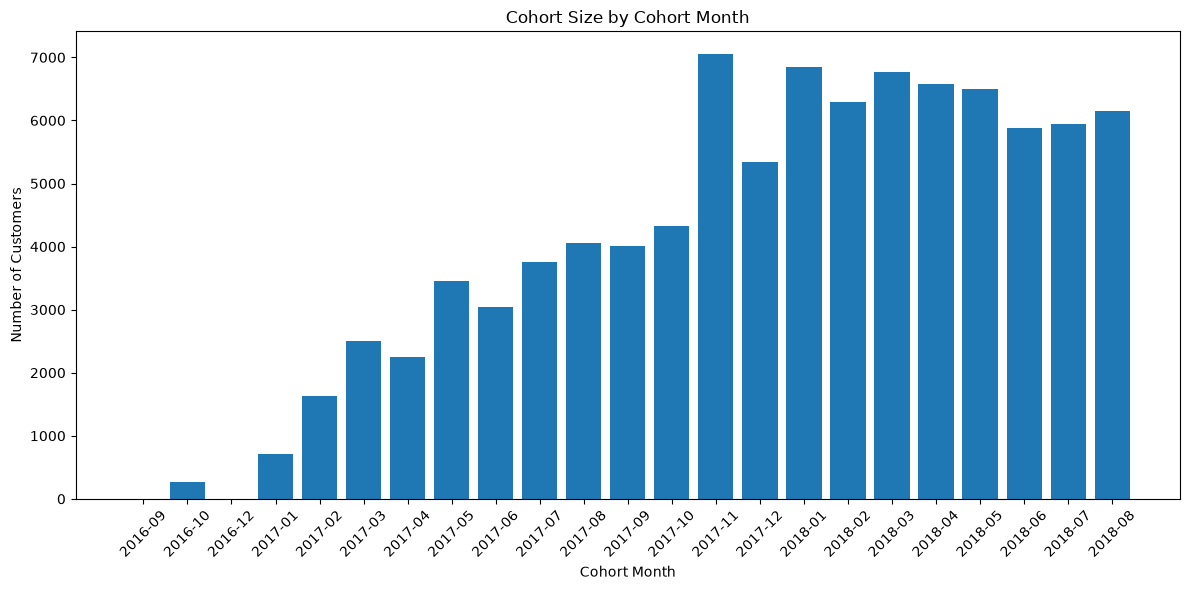

In [43]:
plt.figure(figsize=(12, 6))

plt.bar(
    cohort_sizes["cohort_month"],
    cohort_sizes["cohort_size"]
)

plt.title("Cohort Size by Cohort Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
cohort_revenue.to_sql(
    "cohort_revenue",
    conn,
    if_exists="replace",
    index=False
)

print("cohort_revenue table saved successfully.")

cohort_revenue table saved successfully.


In [45]:
query = """
SELECT
    cohort_month,

    SUM(CASE WHEN period_number = 0 THEN active_customers ELSE 0 END) AS period_0,
    SUM(CASE WHEN period_number = 1 THEN active_customers ELSE 0 END) AS period_1,
    SUM(CASE WHEN period_number = 2 THEN active_customers ELSE 0 END) AS period_2,
    SUM(CASE WHEN period_number = 3 THEN active_customers ELSE 0 END) AS period_3,
    SUM(CASE WHEN period_number = 4 THEN active_customers ELSE 0 END) AS period_4,
    SUM(CASE WHEN period_number = 5 THEN active_customers ELSE 0 END) AS period_5,
    SUM(CASE WHEN period_number = 6 THEN active_customers ELSE 0 END) AS period_6,
    SUM(CASE WHEN period_number = 7 THEN active_customers ELSE 0 END) AS period_7,
    SUM(CASE WHEN period_number = 8 THEN active_customers ELSE 0 END) AS period_8,
    SUM(CASE WHEN period_number = 9 THEN active_customers ELSE 0 END) AS period_9,
    SUM(CASE WHEN period_number = 10 THEN active_customers ELSE 0 END) AS period_10

FROM retention_matrix
GROUP BY cohort_month
ORDER BY cohort_month;
"""

sql_cohort_matrix = pd.read_sql_query(query, conn)

sql_cohort_matrix

,cohort_month,period_0,period_1,period_2,period_3,period_4,period_5,period_6,period_7,period_8,period_9,period_10
0,2016-09,1,0,0,0,0,0,0,0,0,0,0
1,2016-10,262,0,0,0,0,0,1,0,0,1,0
2,2016-12,1,1,0,0,0,0,0,0,0,0,0
3,2017-01,717,2,2,1,3,1,3,1,1,0,3
4,2017-02,1628,3,5,2,7,2,4,3,2,3,2
5,2017-03,2503,11,9,10,9,4,4,8,8,2,9
6,2017-04,2256,14,5,4,6,6,8,7,7,4,6
7,2017-05,3451,16,16,10,10,11,14,5,9,9,9
8,2017-06,3037,15,12,13,9,12,11,7,4,6,9
9,2017-07,3752,20,13,9,11,8,12,4,7,10,8


In [46]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\newto\Desktop\cohort-retention-analysis
['.git', '.ipynb_checkpoints', '.venv', '.venv-1', 'cohort_retention.db', 'cohort_retention_analysis.ipynb', 'data', 'Untitled.ipynb']


In [47]:
import os

print(os.listdir("data"))

['cohort_retention_analysis.ipynb', 'note.md', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'queries.sql']


In [48]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)

Customers: (99441, 5)
Orders: (99441, 8)


In [49]:
print("CUSTOMERS COLUMNS:")
print(customers.columns.tolist())

print("\nORDERS COLUMNS:")
print(orders.columns.tolist())

CUSTOMERS COLUMNS:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS COLUMNS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [50]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

print(orders["order_purchase_timestamp"].dtype)

datetime64[us]


In [51]:
first_purchase = (
    orders.groupby("customer_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase.columns = ["customer_id", "first_purchase_date"]

first_purchase.head()

,customer_id,first_purchase_date
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17


In [52]:
customer_id	first_purchase_date
0	00012a2ce6f8dcda20d059ce98491703	2017-11-14 16:08:26
1	000161a058600d5901f007fab4c27140	2017-07-16 09:40:32
2	0001fd6190edaaf884bcaf3d49edf079	2017-02-28 11:06:43
3	0002414f95344307404f0ace7a26f1d5	2017-08-16 13:09:20
4	000379cdec625522490c315e70c7a9fb	2018-04-02 13:42:17


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (750709650.py, line 2)

In [53]:
first_purchase = (
    orders.groupby("customer_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase.columns = ["customer_id", "first_purchase_date"]

first_purchase.head()

,customer_id,first_purchase_date
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17


In [54]:
first_purchase["cohort_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
)

first_purchase.head()

,customer_id,first_purchase_date,cohort_month
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04


In [55]:
orders = orders.merge(
    first_purchase[["customer_id", "cohort_month"]],
    on="customer_id",
    how="left"
)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02


In [56]:
orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders[["customer_id", "cohort_month", "order_month"]].head()

,customer_id,cohort_month,order_month
0,9ef432eb6251297304e76186b10a928d,2017-10,2017-10
1,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07,2018-07
2,41ce2a54c0b03bf3443c3d931a367089,2018-08,2018-08
3,f88197465ea7920adcdbec7375364d82,2017-11,2017-11
4,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02,2018-02


In [57]:
orders["retention_month"] = (
    (orders["order_month"] - orders["cohort_month"])
    .apply(lambda x: x.n)
)

orders[[
    "customer_id",
    "cohort_month",
    "order_month",
    "retention_month"
]].head(10)

,customer_id,cohort_month,order_month,retention_month
0,9ef432eb6251297304e76186b10a928d,2017-10,2017-10,0
1,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07,2018-07,0
2,41ce2a54c0b03bf3443c3d931a367089,2018-08,2018-08,0
3,f88197465ea7920adcdbec7375364d82,2017-11,2017-11,0
4,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02,2018-02,0
5,503740e9ca751ccdda7ba28e9ab8f608,2017-07,2017-07,0
6,ed0271e0b7da060a393796590e7b737a,2017-04,2017-04,0
7,9bdf08b4b3b52b5526ff42d37d47f222,2017-05,2017-05,0
8,f54a9f0e6b351c431402b8461ea51999,2017-01,2017-01,0
9,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07,2017-07,0


In [58]:
cohort_data = (
    orders.groupby(["cohort_month", "retention_month"])["customer_id"]
    .nunique()
    .reset_index()
)

cohort_data.head(10)

,cohort_month,retention_month,customer_id
0,2016-09,0,4
1,2016-10,0,324
2,2016-12,0,1
3,2017-01,0,800
4,2017-02,0,1780
5,2017-03,0,2682
6,2017-04,0,2404
7,2017-05,0,3700
8,2017-06,0,3245
9,2017-07,0,4026


In [59]:
cohort_matrix = cohort_data.pivot(
    index="cohort_month",
    columns="retention_month",
    values="customer_id"
)

cohort_matrix

retention_month,0
cohort_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


In [60]:
orders_retention = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

orders_retention[
    ["customer_id", "customer_unique_id"]
].head()

,customer_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff
1,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231
2,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8
3,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977
4,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6


In [61]:
first_purchase_unique = (
    orders_retention
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase_unique.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

first_purchase_unique.head()

,customer_unique_id,first_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [62]:
first_purchase_unique["cohort_month"] = (
    first_purchase_unique["first_purchase_date"]
    .dt.to_period("M")
)

first_purchase_unique.head()

,customer_unique_id,first_purchase_date,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11


In [63]:
orders_retention = orders_retention.merge(
    first_purchase_unique[
        ["customer_unique_id", "cohort_month"]
    ],
    on="customer_unique_id",
    how="left"
)

orders_retention[
    ["customer_unique_id", "cohort_month"]
].head()

KeyError: "['cohort_month'] not in index"

In [64]:
print(orders_retention.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'cohort_month_x', 'order_month', 'retention_month', 'customer_unique_id', 'cohort_month_y']


In [65]:
orders_retention["cohort_month"] = orders_retention["cohort_month_y"]

orders_retention[
    ["customer_unique_id", "cohort_month"]
].head()

,customer_unique_id,cohort_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02


In [66]:
orders_retention["order_month"] = (
    orders_retention["order_purchase_timestamp"]
    .dt.to_period("M")
)

orders_retention[
    ["customer_unique_id", "cohort_month", "order_month"]
].head(10)

,customer_unique_id,cohort_month,order_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07
6,36edbb3fb164b1f16485364b6fb04c73,2017-04,2017-04
7,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05
8,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07


In [67]:
orders_retention["retention_month"] = (
    (orders_retention["order_month"] - orders_retention["cohort_month"])
    .apply(lambda x: x.n)
)

orders_retention[
    [
        "customer_unique_id",
        "cohort_month",
        "order_month",
        "retention_month"
    ]
].head(10)

,customer_unique_id,cohort_month,order_month,retention_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
6,36edbb3fb164b1f16485364b6fb04c73,2017-04,2017-04,0
7,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
8,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0


In [68]:
cohort_data_unique = (
    orders_retention
    .groupby(["cohort_month", "retention_month"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_data_unique.head(10)

,cohort_month,retention_month,customer_unique_id
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


In [69]:
cohort_matrix_unique = cohort_data_unique.pivot(
    index="cohort_month",
    columns="retention_month",
    values="customer_unique_id"
)

cohort_matrix_unique

retention_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [70]:
retention_matrix = cohort_matrix_unique.divide(
    cohort_matrix_unique.iloc[:, 0],
    axis=0
)

retention_matrix

retention_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN
2017-03,1.0,0.004932,0.003794,0.003794,0.003414,0.001517,0.001517,0.003035,0.003414,0.000759,0.003794,0.001517,0.002276,0.001138,0.001517,0.002276,0.000759,0.001517,NaN,NaN
2017-04,1.0,0.005952,0.002126,0.001701,0.003401,0.002551,0.003401,0.002976,0.002976,0.001701,0.002551,0.000850,0.000850,0.000425,0.000850,0.000850,0.002126,NaN,NaN,NaN
2017-05,1.0,0.005006,0.005006,0.003893,0.003059,0.003337,0.004171,0.001669,0.002503,0.003059,0.002503,0.003337,0.002503,0.000278,0.001947,0.002503,NaN,NaN,NaN,NaN
2017-06,1.0,0.004779,0.003504,0.004141,0.002549,0.003823,0.003823,0.002230,0.001274,0.002230,0.003186,0.003504,0.001593,0.001274,0.001911,NaN,NaN,NaN,NaN,NaN


In [71]:
retention_matrix_pct = retention_matrix * 100

retention_matrix_pct.round(2)

retention_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.31,NaN,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,NaN,0.31,0.62,0.62
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,NaN,0.39,0.13,0.79,0.39,0.13,0.13,0.26,0.39,0.13,NaN
2017-02,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17,0.17,0.11,0.06,0.06,0.23,NaN,NaN
2017-03,100.0,0.49,0.38,0.38,0.34,0.15,0.15,0.30,0.34,0.08,0.38,0.15,0.23,0.11,0.15,0.23,0.08,0.15,NaN,NaN
2017-04,100.0,0.60,0.21,0.17,0.34,0.26,0.34,0.30,0.30,0.17,0.26,0.09,0.09,0.04,0.09,0.09,0.21,NaN,NaN,NaN
2017-05,100.0,0.50,0.50,0.39,0.31,0.33,0.42,0.17,0.25,0.31,0.25,0.33,0.25,0.03,0.19,0.25,NaN,NaN,NaN,NaN
2017-06,100.0,0.48,0.35,0.41,0.25,0.38,0.38,0.22,0.13,0.22,0.32,0.35,0.16,0.13,0.19,NaN,NaN,NaN,NaN,NaN


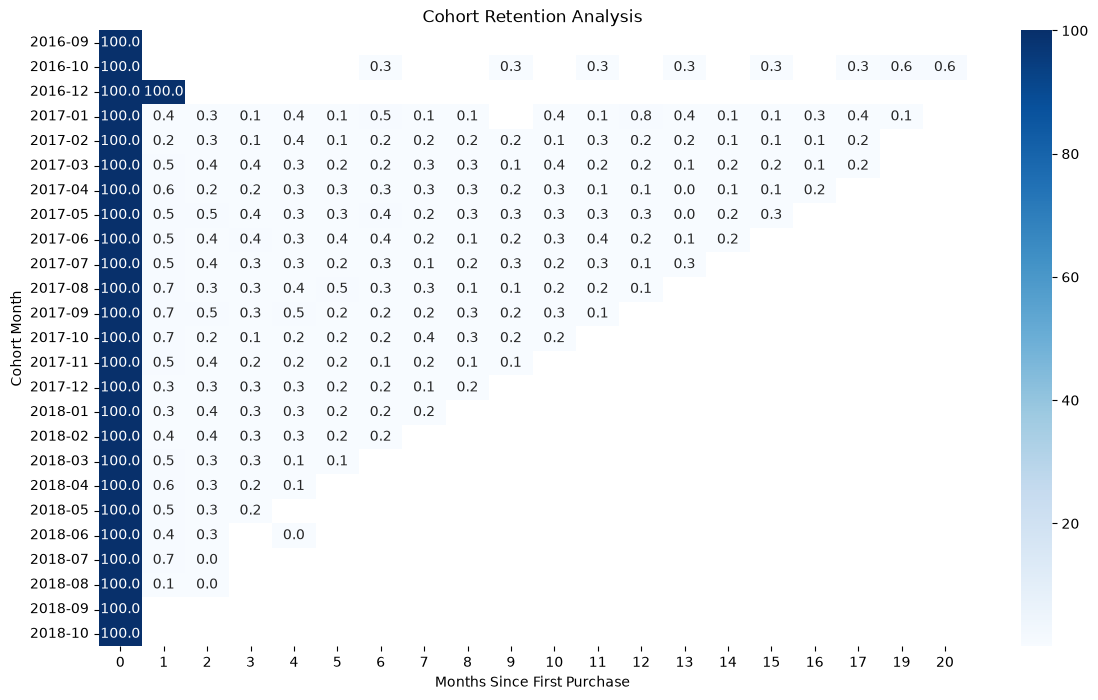

In [72]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Cohort Retention Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

In [73]:
retention_matrix_pct.iloc[:, 1:].max().max()

np.float64(100.0)

In [74]:
retention_matrix_pct.iloc[:, 1:].stack().max()

np.float64(100.0)

In [75]:
retention_matrix_pct[1].dropna().mean()

np.float64(5.22020728266193)

In [76]:
retention_matrix_pct[2].dropna().mean()

np.float64(0.30716253912011754)

In [77]:
retention_matrix_pct[3].dropna().mean()

np.float64(0.2551859027058137)

print("Average 1-month retention:", round(retention_matrix_pct[1].dropna().mean(), 2), "%")
print("Average 2-month retention:", round(retention_matrix_pct[2].dropna().mean(), 2), "%")
print("Average 3-month retention:", round(retention_matrix_pct[3].dropna().mean(), 2), "%")

## Insights

- The average 1-month retention rate is **5.22%**.
- The average 2-month retention rate decreases to **0.31%**.
- The average 3-month retention rate is **0.26%**.
- The results show a significant drop in customer retention after the first month.
- The cohort heatmap shows that most customers do not make another purchase in the following months.
- Retention rates vary across cohorts, but the general pattern is a strong decline after the first purchase month.